In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary
from pump_probe import DataCollector, SignalProcessor, LifetimeFitter, Plotter
import math

from pathlib import Path
import re

In [2]:
from scipy.signal import find_peaks, peak_widths

In [3]:
dc = DataCollector()
sp = SignalProcessor()
pl = Plotter()
lt = LifetimeFitter()

In [4]:
path_com = '/Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Pump probe/Composition_OP.xlsx'
df_compo = pd.read_excel(path_com)
com_Cu = df_compo.sort_values("Cu_Real",ascending=False)['Composition'].to_numpy()
com_Ni = df_compo.sort_values("Ni_Real",ascending=False)['Composition'].to_numpy()
com_Al = df_compo.sort_values("Al_Real",ascending=False)['Composition'].to_numpy()

In [5]:
df_compo = df_compo.copy()
df_compo = df_compo.dropna()

df_compo['Cu'] = (df_compo["Cu"] * 100).round(2)
df_compo['Ni'] = (df_compo["Ni"] * 100).round(2)
df_compo['Al'] = (df_compo["Al"] * 100).round(2)

df_compo["symbol"] = (
    "Cu" + df_compo["Cu"].astype(str) +
    " Ni" + df_compo["Ni"].astype(str) +
    " Al" + df_compo["Al"].astype(str)
)

In [6]:
df_compo_2 = df_compo.copy()
df_compo_2 = df_compo_2.dropna()

df_compo_2['Cu'] = (df_compo_2["Cu_Real"] * 100).round(2)
df_compo_2['Ni'] = (df_compo_2["Ni_Real"] * 100).round(2)
df_compo_2['Al'] = (df_compo_2["Al_Real"] * 100).round(2)

df_compo_2["symbol"] = (
    "Cu" + df_compo_2["Cu"].astype(str) +
    " Ni" + df_compo_2["Ni"].astype(str) +
    " Al" + df_compo_2["Al"].astype(str)
)

In [7]:
FOLDER = Path("/Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Pump probe/_1st_bad_data_no_removed")

pattern = re.compile(
    r"""
    sample(?P<sample>\d+)       # sample12
    .*?                         # anything in between (important!)
    pump_                       # pump_
    (?P<power>\d+)p0mW          # 10p0mW → captures 10
    """,
    
    re.VERBOSE
)

rows = []

for fp in FOLDER.glob("*.csv"):
    m = pattern.search(fp.name)
    if not m:
        #print('NoFoundFile')
        continue

    meta = {
        "file": fp.name,
        "sample": int(m.group("sample")),
        "power_mW": int(m.group("power")),
        "path": str(fp),
    }
    rows.append(meta)


# A metadata index of files
files_index = pd.DataFrame(rows).sort_values(["sample","power_mW"])

In [8]:
idx = files_index.groupby("sample")["power_mW"].idxmax()
selected = files_index.loc[idx].sort_values("sample")
#selected = files_index.query(" power_mW== 8")

In [9]:
all_data = []

for _, row in selected.iterrows():
    df = dc.load_csv(row["path"],round_cols=3,low=0,high=38.8)
    df_p = sp.denoise_df_by_wvl(df)

    df_p = df_p.assign(
        sample=int(row["sample"]),
        power_mW=float(row["power_mW"])
    )

    all_data.append(df_p)

master = pd.concat(all_data)

master_dfs = {
    sample: g.copy()
    for sample, g in master.groupby("sample")
}

# Wavelength plots
1. Plots as Cu decreases
2. Plots as Ni decreases
3. Plots as Al decreases

- Electron-phono coupling 1ps-100 ps


In [10]:
def estimate_noise(y):
    dy = np.diff(y)
    mad = np.median(np.abs(dy - np.median(dy)))
    return 1.4826 * mad   # ≈ std for Gaussian noise

def peak_info(df, time):
    df = df.drop(columns=["sample", "power_mW"])
    df = df.loc[:, ~df.columns.duplicated()]
    
    x = np.array(list(df.index))
    y = df[time].to_numpy()
    
    noise = estimate_noise(y)
    prominence = noise*3
    
    # positive peaks
    peaks_pos, props_pos = find_peaks(y, prominence=prominence)
    # negative peaks (minima)
    peaks_neg, props_neg = find_peaks(-y, prominence=prominence)
    
    peak_x_pos = x[peaks_pos]
    peak_y_pos = y[peaks_pos]
    
    peak_x_neg = x[peaks_neg]
    peak_y_neg = y[peaks_neg]
    
    # Peaks summary information
    t_peak_x = np.concatenate((peak_x_pos,peak_x_neg))
    t_peak_y = np.concatenate((np.abs(peak_y_pos),np.abs(peak_y_neg)))
    
    avg_intensity = np.mean(t_peak_y)
    max_intensity = np.max(t_peak_y)
    max_po = np.argmax(t_peak_y)
    max_peak = t_peak_x[max_po]
    
    return (avg_intensity,max_peak,max_intensity)

In [11]:
rows = []

cols = np.array(df.columns, dtype=float)

target = 0.8
time = cols[np.argmin(np.abs(cols - target))]

for key in master_dfs.keys():
    avg_intensity,max_peak,max_intensity = peak_info(master_dfs[key],time)
    
    rows.append({
        'sample': key,
        'Cu': int(df_compo.loc[df_compo['Composition'] == key, 'Cu'].iloc[0]*100),
        'Ni': int(df_compo.loc[df_compo['Composition'] == key, 'Ni'].iloc[0]*100),
        'Al': int(df_compo.loc[df_compo['Composition'] == key, 'Al'].iloc[0]*100),
        'avg_intensity': avg_intensity,
        'max_peak': max_peak,
        'max_intensity': max_intensity
    })

df_peaks_info = pd.DataFrame(rows)

#cols_to_save = ["Cu", "Ni", "Al", 'max_peak'] 
#df_peaks_info[cols_to_save].to_excel("my_data.xlsx", index=True)

In [12]:
target = 0.3
time = cols[np.argmin(np.abs(cols - target))]

df = master_dfs[1]
df = df.drop(columns=["sample", "power_mW"])
df = df.loc[:, ~df.columns.duplicated()]
x = np.array(list(df.index))
y = df[time].to_numpy()

noise = estimate_noise(y)
prominence = noise*100
    
# positive peaks
peaks_pos, props_pos = find_peaks(y, prominence=prominence)
# negative peaks (minima)
peaks_neg, props_neg = find_peaks(-y, prominence=prominence)
    
peak_x_pos = x[peaks_pos]
peak_y_pos = y[peaks_pos]
    
peak_x_neg = x[peaks_neg]
peak_y_neg = y[peaks_neg]

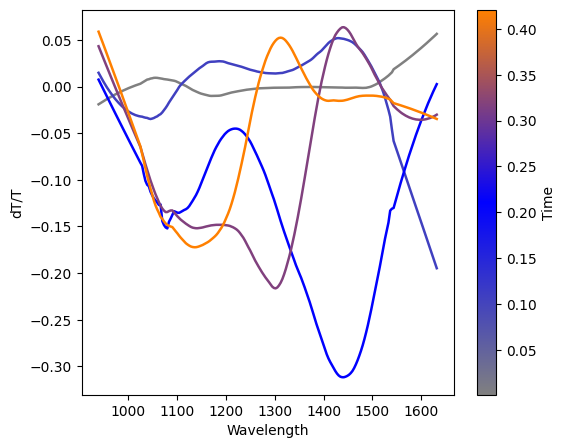

In [13]:
pl.plot_columns_in_range(
    df,
    low_time=0, high_time=0.5,step=3,
    legend=False,figsize=(6,5)
)
plt.savefig("Pump_probe.svg", bbox_inches="tight")
#plt.show()

In [14]:
low=-2
high=1
step = 1
cols = df.columns.to_numpy(dtype=float)
cols_un = np.unique(cols)
col_range = cols_un[(cols_un >= low) & (cols_un <= high)][::step]
y = df[col_range]

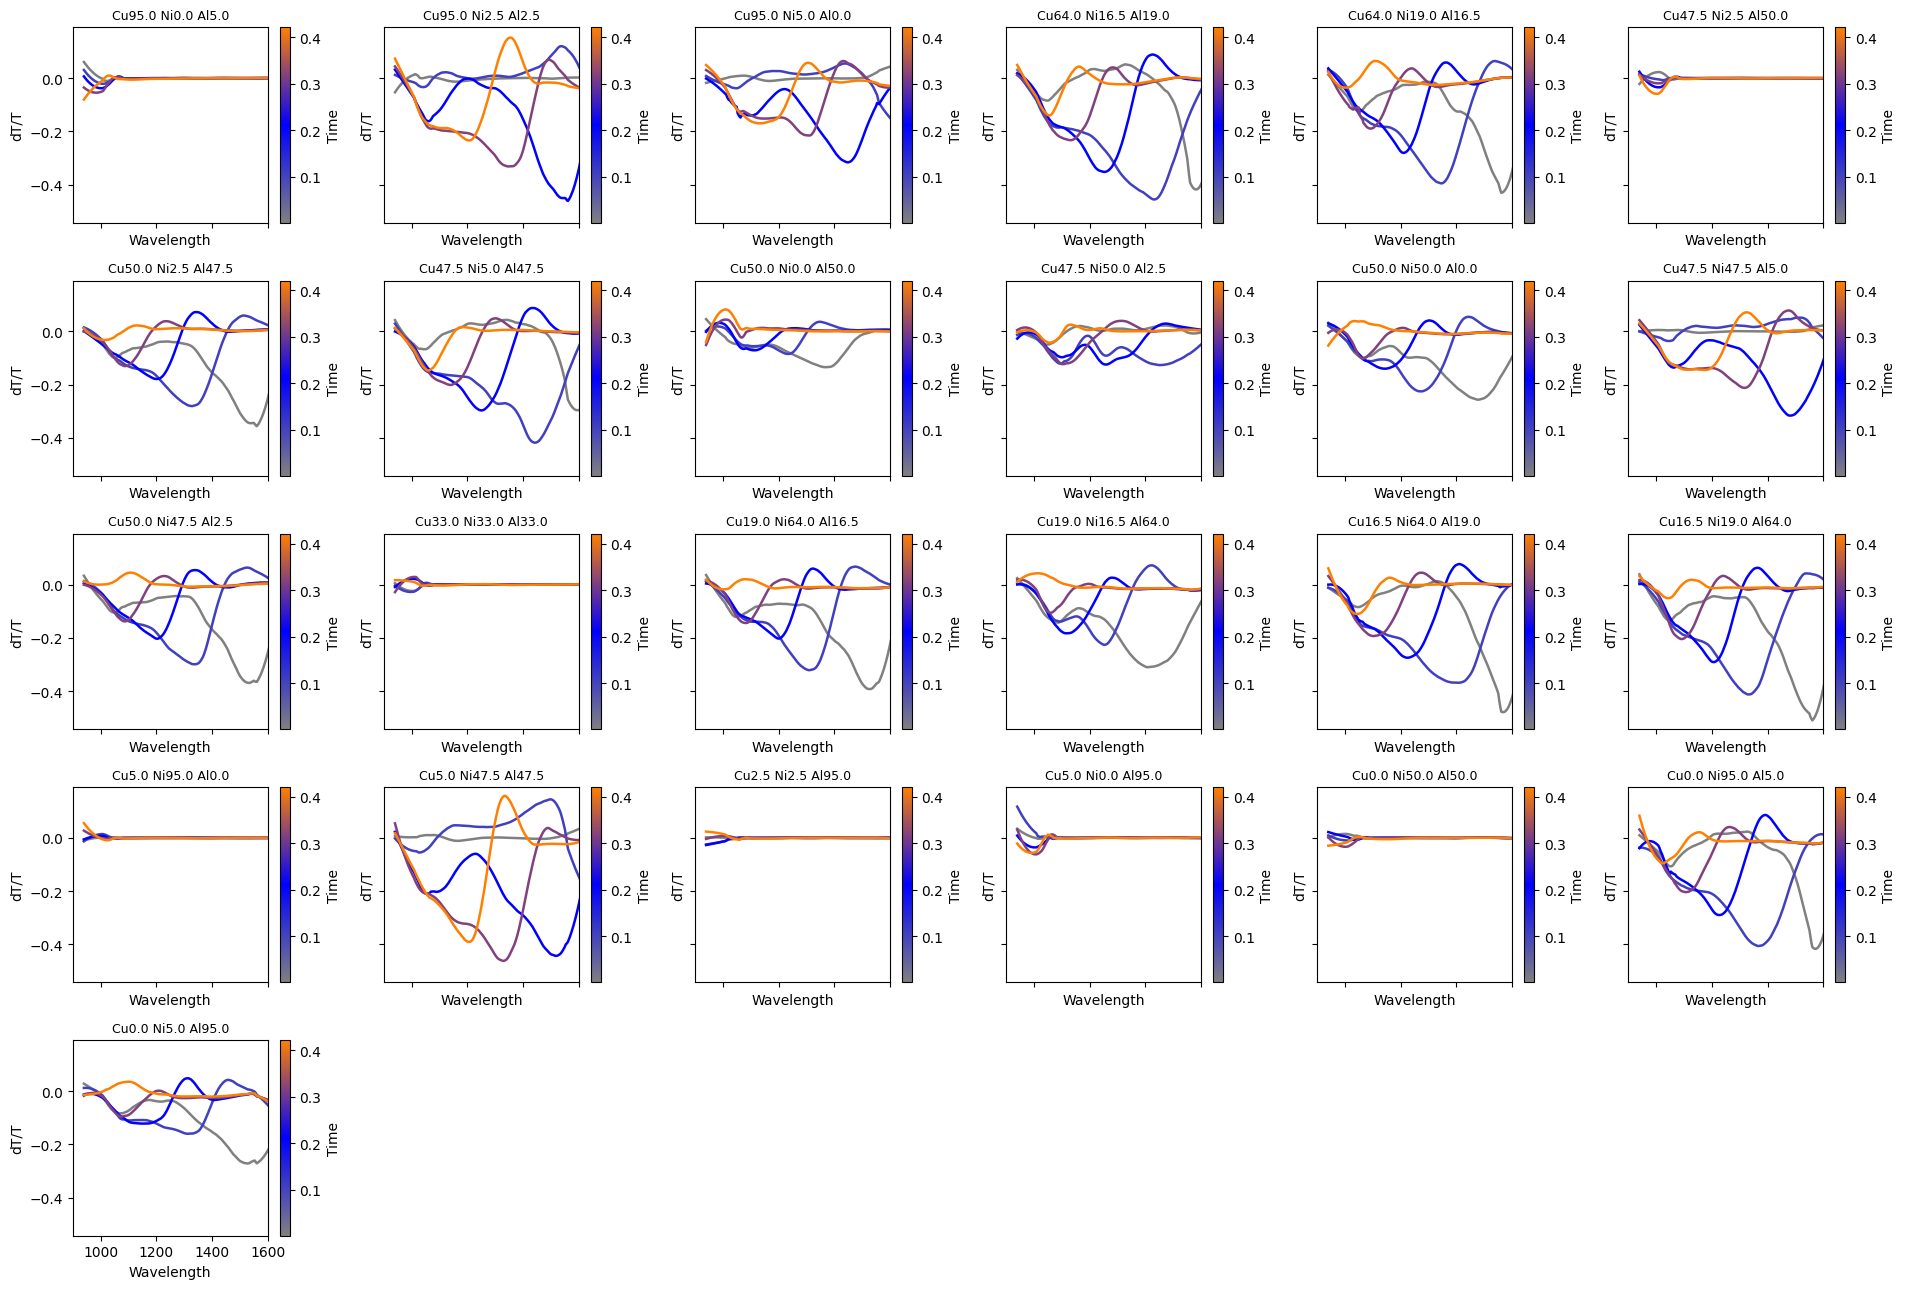

In [15]:
sample_data = np.array(list(master_dfs.keys()))
samp_cu = com_Cu[np.isin(com_Cu,sample_data)]
n = len(samp_cu)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()  # flatten to 1D list of axes

for ax, sample in zip(axes, samp_cu):
    df = master_dfs[sample]
    df = df.drop(columns=['sample', 'power_mW'])
    pl.plot_columns_in_range(df, low_time=0, high_time=0.5,step=3,ax=ax,xlim=[900,1600],legend=False)
    title = df_compo.loc[df_compo["Composition"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

In [ ]:
sample_data = np.array(list(master_dfs.keys()))
samples = [8,17,10]

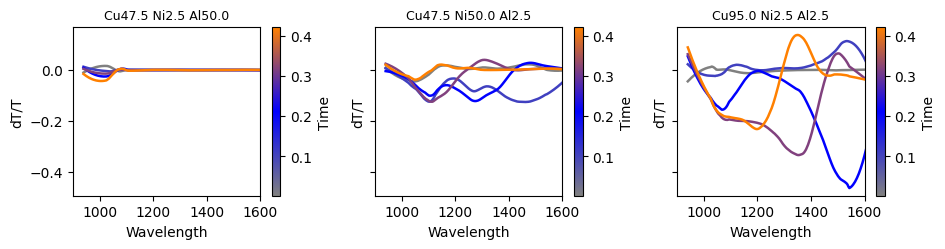

In [27]:
sample_data = np.array(list(master_dfs.keys()))
samp_cu = [17,9,8]
n = len(samp_cu)

ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()  # flatten to 1D list of axes

for ax, sample in zip(axes, samp_cu):
    df = master_dfs[sample]
    df = df.drop(columns=['sample', 'power_mW'])
    pl.plot_columns_in_range(df, low_time=0, high_time=0.5,step=3,ax=ax,xlim=[900,1600],legend=False)
    title = df_compo.loc[df_compo["Composition"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
#plt.show()
plt.savefig("Pump_probe.svg", bbox_inches="tight")

## Original Kinetic Plot

In [14]:
all_data = []

for _, row in selected.iterrows():
    df = dc.load_csv(row["path"],round_cols=3,low=0,high=38.8)
    df_p = df

    df_p = df_p.assign(
        sample=int(row["sample"]),
        power_mW=float(row["power_mW"])
    )

    all_data.append(df_p)

master = pd.concat(all_data)

master_dfs = {
    sample: g.copy()
    for sample, g in master.groupby("sample")
}

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from typing import Optional, Tuple, Sequence

def kinetics_plots(
    df: pd.DataFrame,
    figsize: Tuple[int, int] = (8, 6),
    legend: bool = False,

    # ---- wavelength selection ----
    wavelengths: Optional[Sequence[float]] = None,            # exact picks
    wavelength_range: Optional[Tuple[float, float]] = None,   # (low, high)
    wavelength_step: int = 1,

    # ---- axes ----
    xlim: Optional[Tuple[float, float]] = None,
    ylim: Optional[Tuple[float, float]] = None,
    xlabel: str = "Time (ps)",
    ylabel: str = "dT/T",

    # ---- style ----
    linewidth: float = 1.6,
    alpha: float = 0.9,

    # ---- colormap ----
    add_colorbar: bool = True,
    cbar_label: str = "Wavelength (nm)",
    cmap_colors: Tuple[Tuple[int,int,int], Tuple[int,int,int], Tuple[int,int,int]] = (
        (128,128,128),  # gray
        (0,0,255),      # blue
        (255,128,0)     # orange
    ),

    ax=None,
):
    # ---- time axis ----
    time = pd.to_numeric(df.columns, errors="coerce").to_numpy(dtype=float)
    if np.any(np.isnan(time)):
        bad = df.columns[np.isnan(time)]
        raise ValueError(f"Some time columns could not be converted to float: {list(bad)[:10]} ...")

    # ---- wavelength axis (index) ----
    wl_all = pd.to_numeric(df.index, errors="coerce").to_numpy(dtype=float)
    if np.any(np.isnan(wl_all)):
        bad = df.index[np.isnan(wl_all)]
        raise ValueError(f"Some wavelength index values could not be converted to float: {list(bad)[:10]} ...")

    # ---- build wavelength mask ----
    mask = np.ones_like(wl_all, dtype=bool)

    if wavelength_range is not None:
        lo, hi = float(wavelength_range[0]), float(wavelength_range[1])
        if lo <= hi:
            mask &= (wl_all >= lo) & (wl_all <= hi)
        else:
            mask &= (wl_all >= hi) & (wl_all <= lo)

    if wavelengths is not None:
        wavelengths = np.asarray(wavelengths, dtype=float)
        # pick nearest wavelength in index
        mask_exact = np.zeros_like(wl_all, dtype=bool)
        for w in wavelengths:
            idx = int(np.argmin(np.abs(wl_all - w)))
            mask_exact[idx] = True
        mask &= mask_exact

    # apply mask + step
    wl = wl_all[mask][::wavelength_step]
    Y = df.iloc[mask].iloc[::wavelength_step].to_numpy()

    if len(wl) == 0:
        raise ValueError("No wavelengths selected. Check wavelength_range / wavelengths.")

    # ---- custom colormap ----
    def rgb01(rgb255):
        return tuple(c / 255 for c in rgb255)

    gray, blue, orange = map(rgb01, cmap_colors)
    custom_cmap = LinearSegmentedColormap.from_list(
        "wl_cmap", [gray, blue, orange], N=256
    )

    norm = Normalize(vmin=float(np.min(wl)), vmax=float(np.max(wl)))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # ---- plot curves ----
    for wavelength, y in zip(wl, Y):
        ax.plot(
            time,
            y,
            color=custom_cmap(norm(wavelength)),
            linewidth=linewidth,
            alpha=alpha,
            label=f"{wavelength:g} nm"
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    if legend:
        ax.legend(title='Wavelength', fontsize=8)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if add_colorbar:
        sm = ScalarMappable(norm=norm, cmap=custom_cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label(cbar_label)
        return ax

In [16]:
target_wavelengths = np.array([1310, 1550, 1620], dtype=float)
wl_all = pd.to_numeric(df.index, errors="coerce").to_numpy(dtype=float)

nearest_wavelengths = []
for w in target_wavelengths:
    idx = np.argmin(np.abs(wl_all - w))
    nearest_wavelengths.append(wl_all[idx])

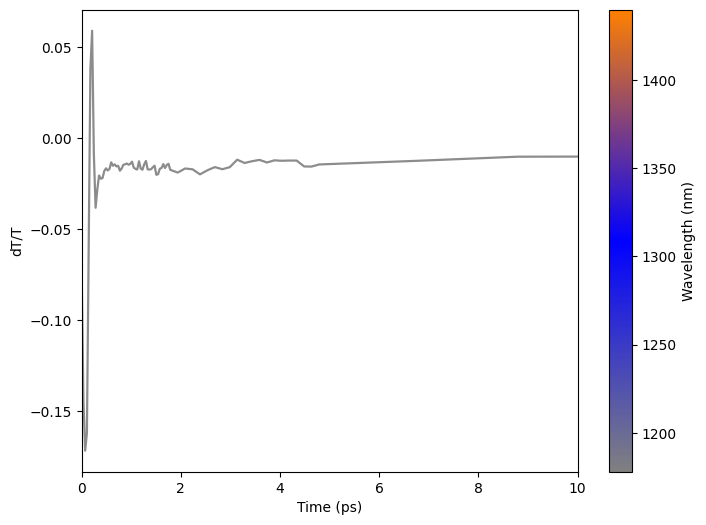

In [20]:
kinetics_plots(
    df,
    wavelengths=[1308.8],
    wavelength_step=1,
    xlim=(0, 10)
)
plt.show()

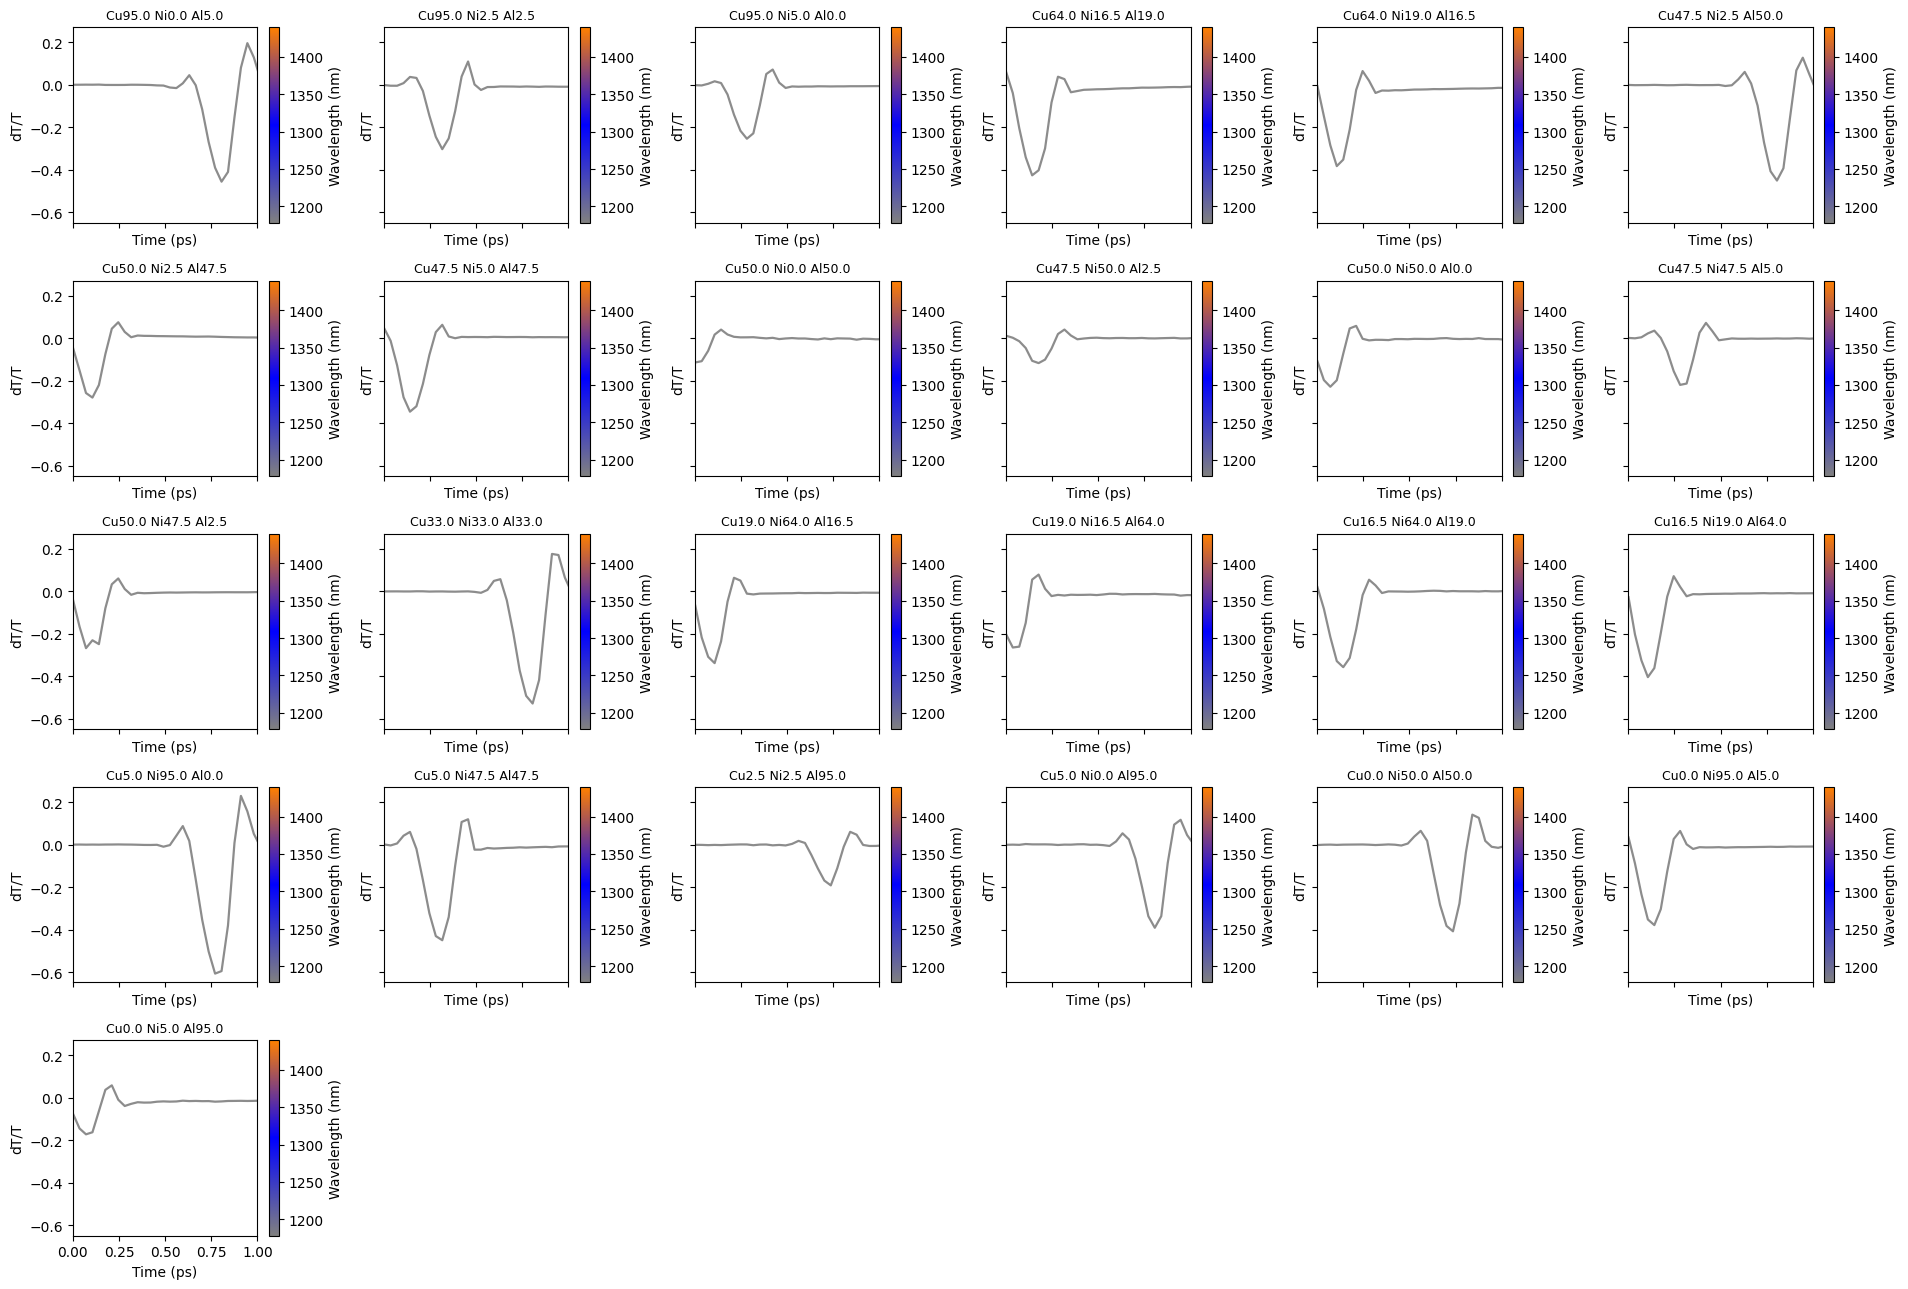

In [18]:
sample_data = np.array(list(master_dfs.keys()))
samp_cu = com_Cu[np.isin(com_Cu,sample_data)]
n = len(samp_cu)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()  # flatten to 1D list of axes

for ax, sample in zip(axes, samp_cu):
    df = master_dfs[sample]
    df = df.drop(columns=['sample', 'power_mW'])
    kinetics_plots(df,wavelengths = [1308.8],wavelength_step=1,xlim=(0, 1),ax=ax )
    title = df_compo.loc[df_compo["Composition"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

Lifetime calculation

In [20]:
df = master_dfs[1]
columns = ['sample','power_mW']
df = df.drop(columns=columns)

In [ ]:
lifetime = {}
wvl = 1308.8

for key, df in master_dfs.items():
    df = df.drop(columns=['sample', 'power_mW'])


    x = df.columns.to_numpy()

    idx = np.abs(df.index.to_numpy(dtype=float) - wvl).argmin()
    y = df.iloc[idx].to_numpy(dtype=float)

    lifetime[key] = lt.fit(time=x, y_exp=y)

In [33]:

def plot_lifetime_fit(
    lifetime: dict,
    key,
    time,
    y_exp,
    time_range=None,          # NEW: (tmin, tmax)
    figsize=(6, 4),
):
    """
    Plot experimental data vs fitted curve for a given key,
    optionally restricting to a time range.
    """

    fit_out = lifetime[key]
    y_fit = fit_out["y_fit"]
    r2 = fit_out.get("r2", None)

    time = np.asarray(time, dtype=float)
    y_exp = np.asarray(y_exp, dtype=float)
    y_fit = np.asarray(y_fit, dtype=float)

    if time_range is not None:
        tmin, tmax = time_range
        mask = (time >= tmin) & (time <= tmax)
    else:
        mask = slice(None)

    plt.figure(figsize=figsize)
    plt.plot(time[mask], y_exp[mask], "o", label="exp")

    if r2 is not None:
        plt.plot(time[mask], y_fit[mask], "-", label=f"fit (R² = {r2:.3f})")
    else:
        plt.plot(time[mask], y_fit[mask], "-", label="fit")

    if time_range is not None:
        plt.xlim(time_range)

    plt.xlabel("Time (ps)")
    plt.ylabel("dT/T")
    plt.legend()
    plt.tight_layout()
    plt.show()

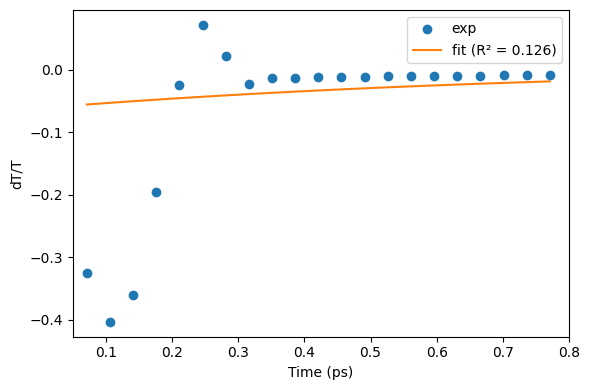

In [34]:
plot_lifetime_fit(
    lifetime=lifetime,
    key=1,
    time=x,
    y_exp=y,
    time_range=(0.05, 0.8),
)

Lifetime equation fitting
1. Functions of the equation and the objective function
2. Find initial guesses
3. Gradient-based search to find the minimum

In [135]:
path_test = 'sara_test_data.xlsx'
df_test = pd.read_excel(path_test,sheet_name='Au50Pd50')

df_test.head(5)
y_exp = df_test['dT/T exp'].to_numpy()
time = df_test['time (ps)'].to_numpy()
y_fit_sara = df_test['dT/T Fit'].to_numpy()

In [117]:
def model(time, dt_t_nt, tau_th, tau_p, dt_t_th, dt_t_l):
    return (
        dt_t_nt * np.exp(-time * ((1/tau_th) + (1/tau_p)))
        + dt_t_th * (np.exp(-time/tau_p) * (1 - np.exp(-time/tau_th)))
        + dt_t_l
    )

def objective(p, time, y_exp):
    y_fit = model(time, *p)
    r = y_fit - y_exp
    return np.sum(r*r)

def find_initial_guess(bounds, time, y_exp, n_samples=5000, seed=0):
    rng = np.random.default_rng(seed)

    lo = np.array([b[0] for b in bounds], dtype=float)
    hi = np.array([b[1] for b in bounds], dtype=float)

    best_p = None
    best_val = np.inf

    for _ in range(n_samples):
        p = lo + (hi - lo) * rng.random(len(bounds))
        val = objective(p, time, y_exp)
        if val < best_val:
            best_val = val
            best_p = p

    return best_p, best_val

In [143]:
def find_initial_guesses(bounds, time, y_exp, n_samples=5000, k_best=20, seed=0):
    rng = np.random.default_rng(seed)

    lo = np.array([b[0] for b in bounds], dtype=float)
    hi = np.array([b[1] for b in bounds], dtype=float)

    candidates = []

    for _ in range(n_samples):
        p = lo + (hi - lo) * rng.random(len(bounds))
        val = objective(p, time, y_exp)
        candidates.append((val, p))

    candidates.sort(key=lambda x: x[0])
    return [p for (_, p) in candidates[:k_best]]

In [149]:

y_scale = np.std(y_exp) if np.std(y_exp) > 0 else 1.0
tmin_pos = np.min(time[time > 0])
tmax = np.max(time)

bounds = [
    (-10*y_scale, 10*y_scale),   # dt_t_nt
    (tmin_pos*0.1, tmax*10),     # tau_th  (ps)
    (tmin_pos*0.1, tmax*10),     # tau_p   (ps)
    (-10*y_scale, 10*y_scale),   # dt_t_th
    (np.min(y_exp), np.max(y_exp))  # dt_t_l
]

p0, val0 = find_initial_guess(bounds, time, y_exp, n_samples=5000)

#--------- Solve equation for Local Minimum -----------------------#
lb = [b[0] for b in bounds]
ub = [b[1] for b in bounds]

scale = np.std(y_exp)
scale = scale if scale > 0 else 1.0

res = least_squares(
    fun=lambda p: (model(time, *p) - y_exp) / scale,
    x0=p0,
    bounds=(lb, ub),
    loss="linear"  # or "soft_l1" if you have outliers
)

p_opt = res.x
print("DE initial:", p0)
print("Refined:", p_opt)


DE initial: [-2.46303905e-02  3.29253229e+01  1.03636743e+00 -9.58679906e-02
  5.82287780e-03]
Refined: [-0.00616366  0.11890152  1.08341281 -0.04387921  0.01092919]


In [ ]:
p0_sara = [-1.08e-2,0.139898,0.74371,-6.28e-2,0.017520945]

In [150]:
y_fit = model(time, *p_opt)
residuals = (y_fit - y_exp)**2
mse = np.mean(residuals)
print('MSE:',mse)

residual_s = (y_fit_sara - y_exp)**2
mse_s = np.mean(residual_s)
print('MSE:',mse_s)

MSE: 1.2135957058256118e-06
MSE: 1.2135957117079583e-06


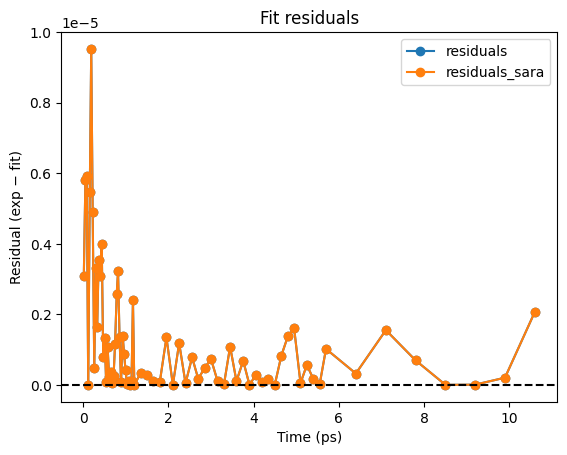

In [139]:
plt.plot(time, residuals, marker='o', label='residuals')
plt.plot(time, residual_s, marker='o', label='residuals_sara')

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Time (ps)")
plt.ylabel("Residual (exp − fit)")
plt.title("Fit residuals")
plt.legend()
plt.show()

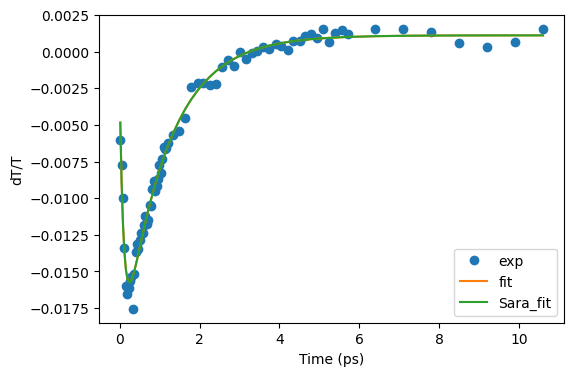

In [131]:
plt.figure(figsize=(6,4))
plt.plot(time, y_exp, 'o', label="exp")
plt.plot(time, y_fit, '-', label="fit")
plt.plot(time, y_fit_sara, '-', label="Sara_fit")
plt.xlabel("Time (ps)")
plt.ylabel("dT/T")
plt.legend()
plt.show()